# 📊 Marketing A/B Test — End-to-End Data Science Pipeline
**Dataset:** `marketing_AB.csv`  
**Target:** `converted` (binary classification)  
**Goal:** Predict conversion and understand what drives it across ad vs PSA groups

---
### Pipeline Overview
1. Setup & Install
2. Load & Inspect Data
3. Data Cleaning
4. Column Exploration (Numerical + Categorical)
5. Univariate Analysis
6. Bivariate Analysis
7. Multivariate Analysis
8. Correlation Heatmap
9. Statistical Tests (A/B Test Significance)
10. Feature Engineering
11. Encode Categorical Columns
12. Train/Test Split
13. Handle Class Imbalance (SMOTE)
14. Train/Validation Split
15. Build & Train Model (Random Forest)
16. Confusion Matrix
17. Feature Importance
18. Hyperparameter Tuning (RandomizedSearchCV)
19. Final Evaluation
20. Save & Reload Trained Model

## 1. 🔧 Setup & Install

In [1]:
# Install required libraries
!pip install -q imbalanced-learn scikit-learn pandas numpy matplotlib seaborn scipy joblib

In [2]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

# Scipy for statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pointbiserialr

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    accuracy_score, average_precision_score
)
from sklearn.inspection import permutation_importance

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3d5c',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#a0a0c0',
    'ytick.color': '#a0a0c0',
    'text.color': '#e0e0e0',
    'grid.color': '#2a2d3e',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'monospace'
})
PALETTE = ['#7c6af7', '#f7a26a', '#4ecdc4', '#ff6b6b', '#a8e6cf']
print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 2. 📂 Load & Inspect Data

In [3]:
# ── Upload via Colab file picker (run this cell first) ──
from google.colab import files
uploaded = files.upload()   # select marketing_AB.csv from your machine
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, index_col=0)
print(f'Shape: {df.shape}')
df.head(10)

Saving marketing_AB.csv to marketing_AB (1).csv
Shape: (588101, 6)


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
5,1137664,ad,False,734,Saturday,10
6,1116205,ad,False,264,Wednesday,13
7,1496843,ad,False,17,Sunday,18
8,1448851,ad,False,21,Tuesday,19
9,1446284,ad,False,142,Monday,14


In [4]:
# Basic info
print('=== DataFrame Info ===')
df.info()
print('\n=== First 5 rows ===')
display(df.head())
print('\n=== Descriptive Statistics ===')
display(df.describe(include='all'))

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 27.5+ MB

=== First 5 rows ===


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14



=== Descriptive Statistics ===


,user id,test group,converted,total ads,most ads day,most ads hour
count,588101.0000,588101,588101,588101.0000,588101,588101.0000
unique,NaN,2,2,NaN,7,NaN
top,NaN,ad,False,NaN,Friday,NaN
freq,NaN,564577,573258,NaN,92608,NaN
mean,1310692.2158,NaN,NaN,24.8209,NaN,14.4691
std,202225.9831,NaN,NaN,43.7152,NaN,4.8346
min,900000.0000,NaN,NaN,1.0000,NaN,0.0000
25%,1143190.0000,NaN,NaN,4.0000,NaN,11.0000
50%,1313725.0000,NaN,NaN,13.0000,NaN,14.0000
75%,1484088.0000,NaN,NaN,27.0000,NaN,18.0000


## 3. 🧹 Data Cleaning

In [5]:
# ── Column names ──
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Columns:', df.columns.tolist())

# ── Rename for clarity ──
df.rename(columns={
    'user_id': 'user_id',
    'test_group': 'test_group',
    'converted': 'converted',
    'total_ads': 'total_ads',
    'most_ads_day': 'most_ads_day',
    'most_ads_hour': 'most_ads_hour'
}, inplace=True)

# ── Missing values ──
print('\nMissing values per column:')
print(df.isnull().sum())

# ── Duplicates ──
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
df.drop_duplicates(inplace=True)

# ── Convert `converted` bool → int ──
df['converted'] = df['converted'].astype(int)

# ── Drop user_id (identifier, not a feature) ──
df.drop(columns=['user_id'], inplace=True)

# ── Outlier check on total_ads ──
q1 = df['total_ads'].quantile(0.25)
q3 = df['total_ads'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr   # use 3x IQR — less aggressive
extreme_outliers = (df['total_ads'] > upper_fence).sum()
print(f'\nExtreme outliers in total_ads (> {upper_fence:.0f}): {extreme_outliers}')
# Cap rather than drop — preserve class distribution
df['total_ads_capped'] = df['total_ads'].clip(upper=upper_fence)

print(f'\nClean dataset shape: {df.shape}')
df.head()

Columns: ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']

Missing values per column:
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

Duplicate rows: 0

Extreme outliers in total_ads (> 96): 24825

Clean dataset shape: (588101, 6)


,test_group,converted,total_ads,most_ads_day,most_ads_hour,total_ads_capped
0,ad,0,130,Monday,20,96
1,ad,0,93,Tuesday,22,93
2,ad,0,21,Tuesday,18,21
3,ad,0,355,Tuesday,10,96
4,ad,0,276,Friday,14,96


In [6]:
# ── Validate class balance ──
conv_counts = df['converted'].value_counts()
print('Conversion counts:')
print(conv_counts)
print(f'\nConversion rate: {df["converted"].mean()*100:.2f}%')

Conversion counts:
converted
0    573258
1     14843
Name: count, dtype: int64

Conversion rate: 2.52%


## 4. 🔍 Column Exploration

In [7]:
# ── Identify column types ──
num_cols  = df.select_dtypes(include=[np.number]).columns.difference(['converted']).tolist()
cat_cols  = df.select_dtypes(include='object').columns.tolist()
target    = 'converted'

print(f'Numerical columns  : {num_cols}')
print(f'Categorical columns: {cat_cols}')
print(f'Target             : {target}')

# ── Categorical value counts ──
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

# ── Numerical summary ──
print('\n--- Numerical Summary ---')
display(df[num_cols].describe())

Numerical columns  : ['most_ads_hour', 'total_ads', 'total_ads_capped']
Categorical columns: ['test_group', 'most_ads_day']
Target             : converted

--- test_group ---
test_group
ad     564577
psa     23524
Name: count, dtype: int64

--- most_ads_day ---
most_ads_day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

--- Numerical Summary ---


,most_ads_hour,total_ads,total_ads_capped
count,588101.0000,588101.0000,588101.0000
mean,14.4691,24.8209,21.3707
std,4.8346,43.7152,24.3732
min,0.0000,1.0000,1.0000
25%,11.0000,4.0000,4.0000
50%,14.0000,13.0000,13.0000
75%,18.0000,27.0000,27.0000
max,23.0000,2065.0000,96.0000


## 5. 📈 Univariate Analysis

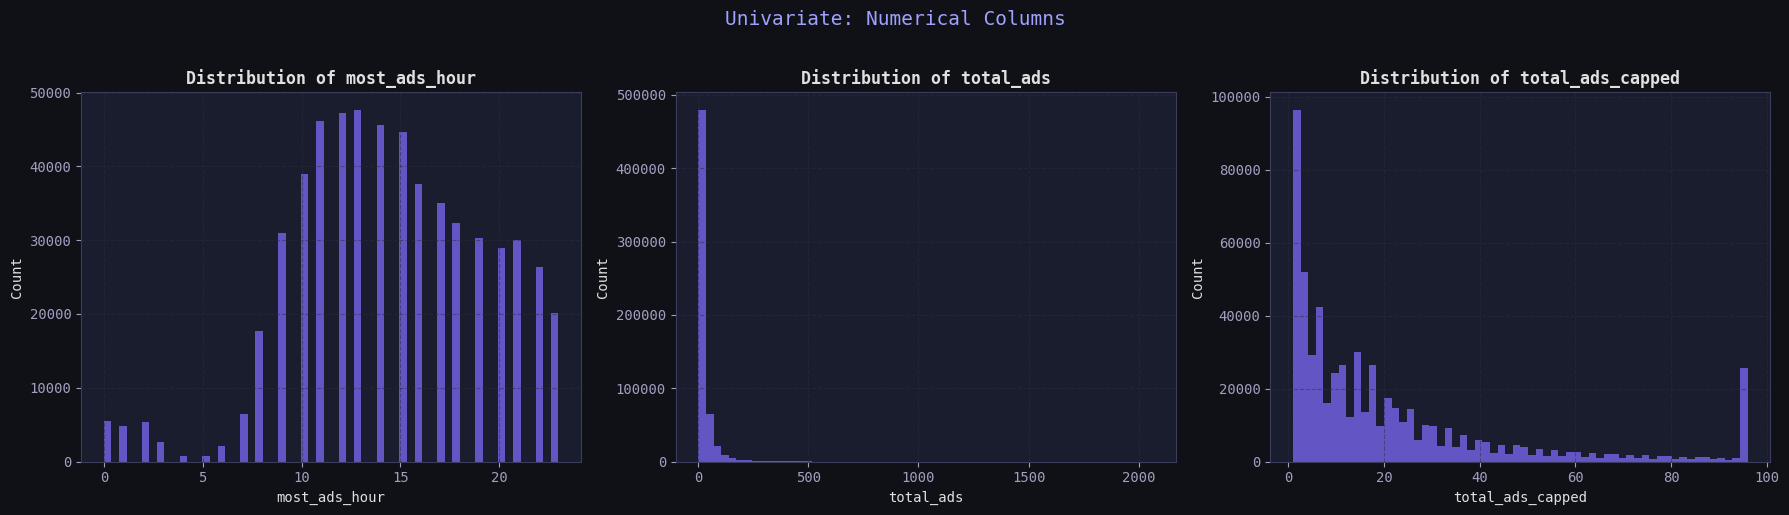

In [8]:
# ── Numerical columns: histogram + KDE ──
fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=60, color=PALETTE[0], alpha=0.75, edgecolor='none')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold', color='#e0e0e0')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(True)

plt.suptitle('Univariate: Numerical Columns', fontsize=14, color='#a0a0ff', y=1.02)
plt.tight_layout()
plt.show()

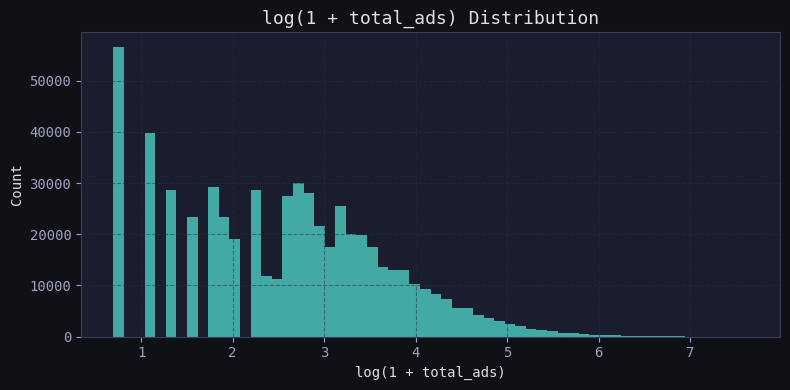

In [9]:
# ── Log-scale histogram for total_ads (highly skewed) ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(df['total_ads']), bins=60, color=PALETTE[2], alpha=0.8, edgecolor='none')
ax.set_title('log(1 + total_ads) Distribution', fontsize=13, color='#e0e0e0')
ax.set_xlabel('log(1 + total_ads)')
ax.set_ylabel('Count')
ax.grid(True)
plt.tight_layout()
plt.show()

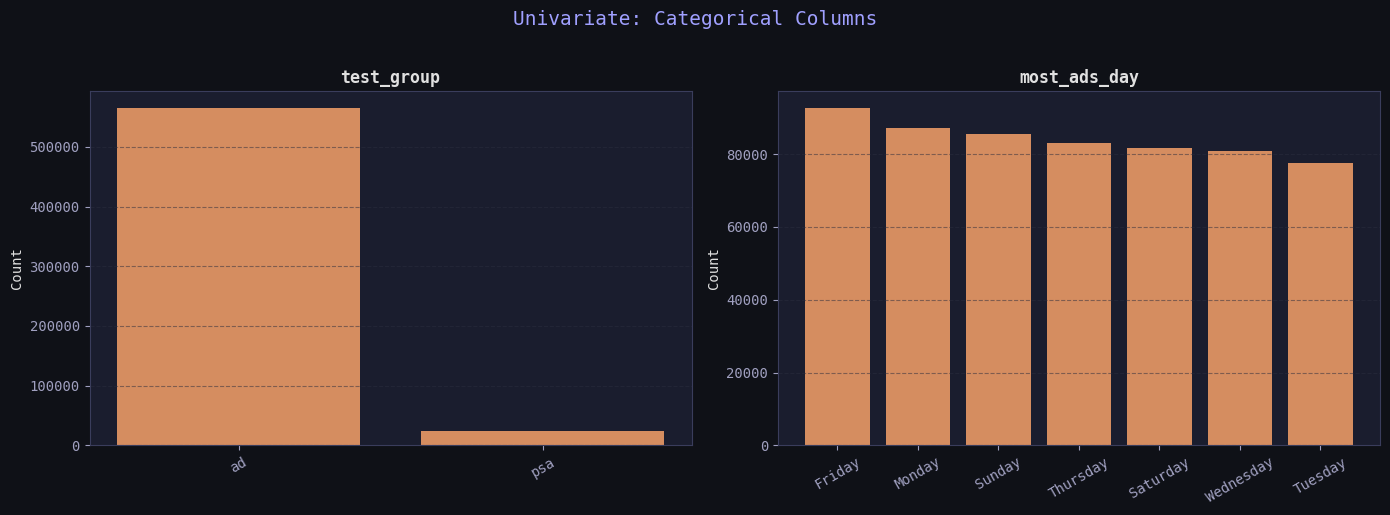

In [10]:
# ── Categorical columns: bar charts ──
fig, axes = plt.subplots(1, len(cat_cols), figsize=(7 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=PALETTE[1], alpha=0.85, edgecolor='none')
    ax.set_title(f'{col}', fontsize=12, fontweight='bold', color='#e0e0e0')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y')

plt.suptitle('Univariate: Categorical Columns', fontsize=14, color='#a0a0ff', y=1.02)
plt.tight_layout()
plt.show()

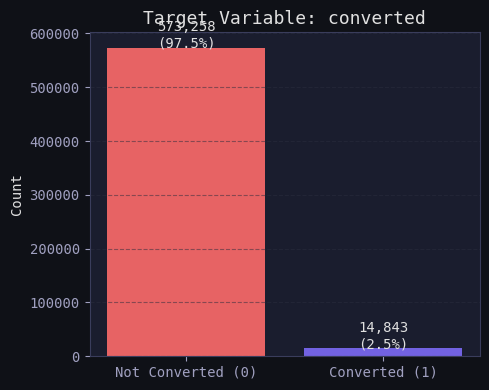

In [11]:
# ── Target distribution ──
fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Not Converted (0)', 'Converted (1)']
counts = df['converted'].value_counts().sort_index()
bars = ax.bar(labels, counts.values, color=[PALETTE[3], PALETTE[0]], alpha=0.9, edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, color='#e0e0e0')
ax.set_title('Target Variable: converted', fontsize=13, color='#e0e0e0')
ax.set_ylabel('Count')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 6. 🔗 Bivariate Analysis

Conversion by Test Group:


,conversion_rate,converted_count,total,conversion_rate_pct
test_group,,,,
ad,0.0255,14423,564577,2.5547
psa,0.0179,420,23524,1.7854


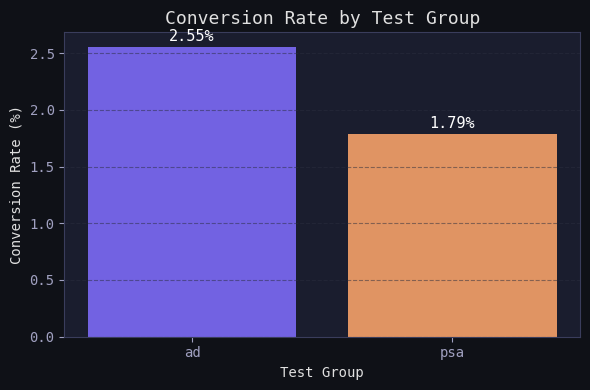

In [12]:
# ── Conversion rate by test_group ──
group_conv = df.groupby('test_group')['converted'].agg(['mean', 'sum', 'count'])
group_conv.columns = ['conversion_rate', 'converted_count', 'total']
group_conv['conversion_rate_pct'] = group_conv['conversion_rate'] * 100
print('Conversion by Test Group:')
display(group_conv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(group_conv.index, group_conv['conversion_rate_pct'], color=PALETTE[:2], alpha=0.9)
ax.set_title('Conversion Rate by Test Group', fontsize=13, color='#e0e0e0')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Test Group')
ax.grid(True, axis='y')
for i, (idx, row) in enumerate(group_conv.iterrows()):
    ax.text(i, row['conversion_rate_pct'] + 0.05, f"{row['conversion_rate_pct']:.2f}%",
            ha='center', fontsize=11, color='white')
plt.tight_layout()
plt.show()

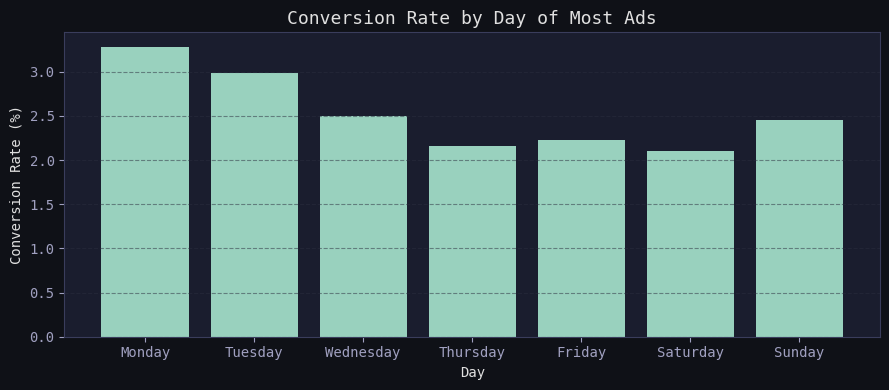

In [13]:
# ── Conversion rate by most_ads_day ──
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_conv = df.groupby('most_ads_day')['converted'].mean().reindex(day_order) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(day_conv.index, day_conv.values, color=PALETTE[4], alpha=0.9)
ax.set_title('Conversion Rate by Day of Most Ads', fontsize=13, color='#e0e0e0')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Day')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

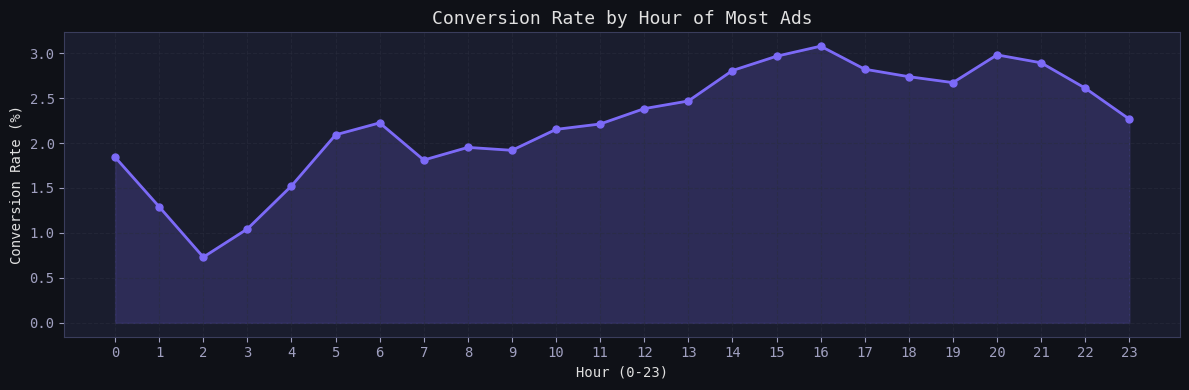

In [14]:
# ── Conversion rate by most_ads_hour ──
hour_conv = df.groupby('most_ads_hour')['converted'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_conv.index, hour_conv.values, color=PALETTE[0], linewidth=2, marker='o', markersize=5)
ax.fill_between(hour_conv.index, hour_conv.values, alpha=0.2, color=PALETTE[0])
ax.set_title('Conversion Rate by Hour of Most Ads', fontsize=13, color='#e0e0e0')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Hour (0-23)')
ax.set_xticks(range(0, 24))
ax.grid(True)
plt.tight_layout()
plt.show()

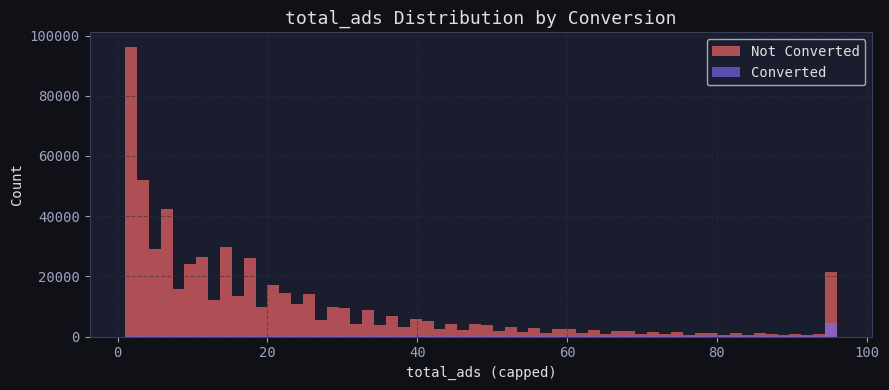

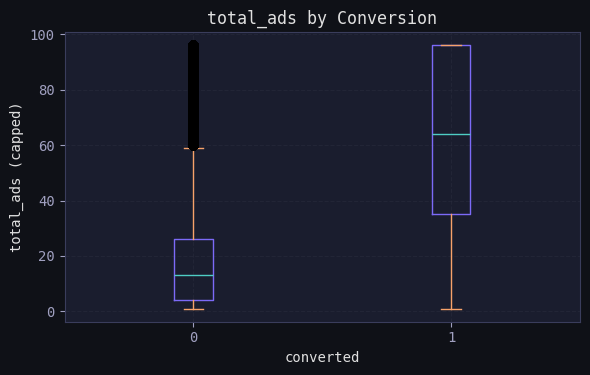

In [15]:
# ── total_ads distribution: converted vs not ──
fig, ax = plt.subplots(figsize=(9, 4))
for val, label, color in zip([0, 1], ['Not Converted', 'Converted'], [PALETTE[3], PALETTE[0]]):
    data = df[df['converted'] == val]['total_ads_capped']
    ax.hist(data, bins=60, alpha=0.65, label=label, color=color, edgecolor='none')
ax.set_title('total_ads Distribution by Conversion', fontsize=13, color='#e0e0e0')
ax.set_xlabel('total_ads (capped)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column='total_ads_capped', by='converted', ax=ax,
           boxprops=dict(color=PALETTE[0]),
           medianprops=dict(color=PALETTE[2]),
           whiskerprops=dict(color=PALETTE[1]),
           capprops=dict(color=PALETTE[1]))
ax.set_title('total_ads by Conversion', color='#e0e0e0')
ax.set_xlabel('converted')
ax.set_ylabel('total_ads (capped)')
plt.suptitle('')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [16]:
# ── Crosstab: test_group × converted ──
ct = pd.crosstab(df['test_group'], df['converted'], margins=True)
print('Crosstab: test_group × converted')
display(ct)

ct_pct = pd.crosstab(df['test_group'], df['converted'], normalize='index') * 100
print('\n% by row:')
display(ct_pct.round(2))

Crosstab: test_group × converted


converted,0,1,All
test_group,,,
ad,550154,14423,564577
psa,23104,420,23524
All,573258,14843,588101



% by row:


converted,0,1
test_group,,
ad,97.4500,2.5500
psa,98.2100,1.7900


## 7. 🌐 Multivariate Analysis

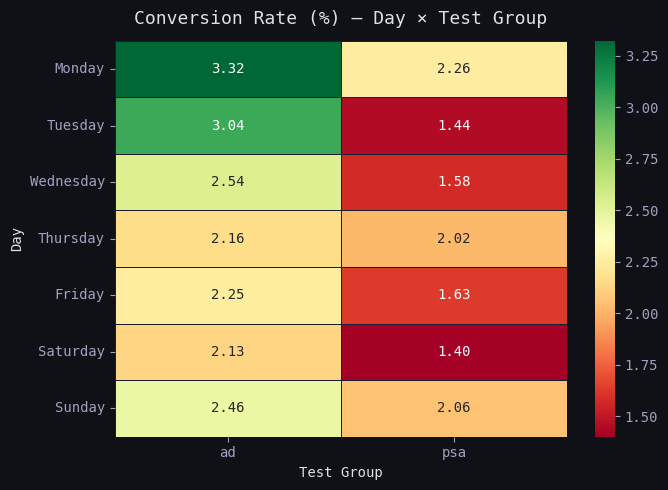

In [17]:
# ── Conversion rate: day × test_group (heatmap) ──
pivot = df.pivot_table(values='converted', index='most_ads_day', columns='test_group', aggfunc='mean') * 100
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='#1a1d2e',
            annot_kws={'size': 10})
ax.set_title('Conversion Rate (%) — Day × Test Group', fontsize=13, color='#e0e0e0', pad=12)
ax.set_xlabel('Test Group')
ax.set_ylabel('Day')
plt.tight_layout()
plt.show()

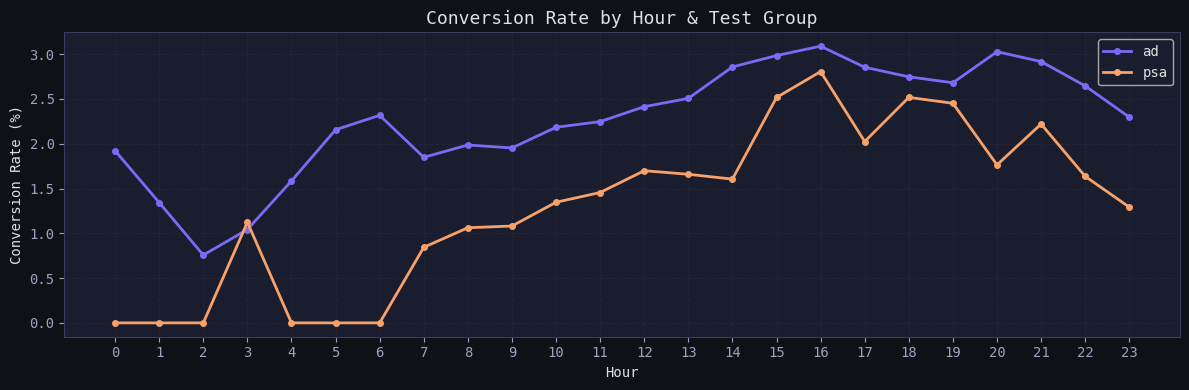

In [18]:
# ── Conversion rate: hour × test_group (line plot) ──
hour_group = df.groupby(['most_ads_hour', 'test_group'])['converted'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(12, 4))
for col, color in zip(hour_group.columns, PALETTE):
    ax.plot(hour_group.index, hour_group[col], label=col, color=color, linewidth=2, marker='o', markersize=4)
ax.set_title('Conversion Rate by Hour & Test Group', fontsize=13, color='#e0e0e0')
ax.set_xlabel('Hour')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

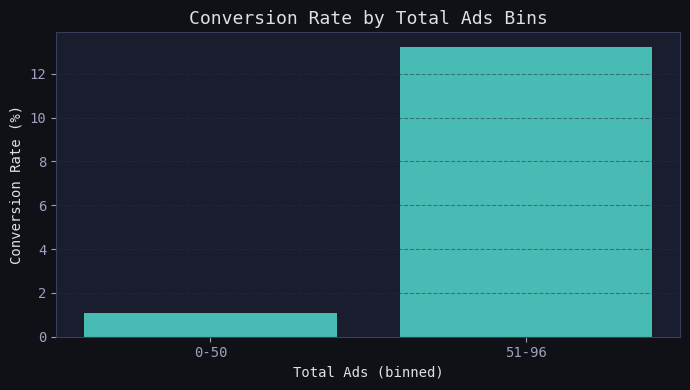

In [19]:
# ── total_ads bins × conversion rate ──
df['ads_bin'] = pd.cut(df['total_ads_capped'],
                       bins=[0, 50, df['total_ads_capped'].max() + 1],
                       labels=['0-50', '51-96'])

bin_conv = df.groupby('ads_bin')['converted'].mean() * 100
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bin_conv.index.astype(str), bin_conv.values, color=PALETTE[2], alpha=0.9)
ax.set_title('Conversion Rate by Total Ads Bins', fontsize=13, color='#e0e0e0')
ax.set_xlabel('Total Ads (binned)')
ax.set_ylabel('Conversion Rate (%)')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 8. 🌡️ Correlation Heatmap

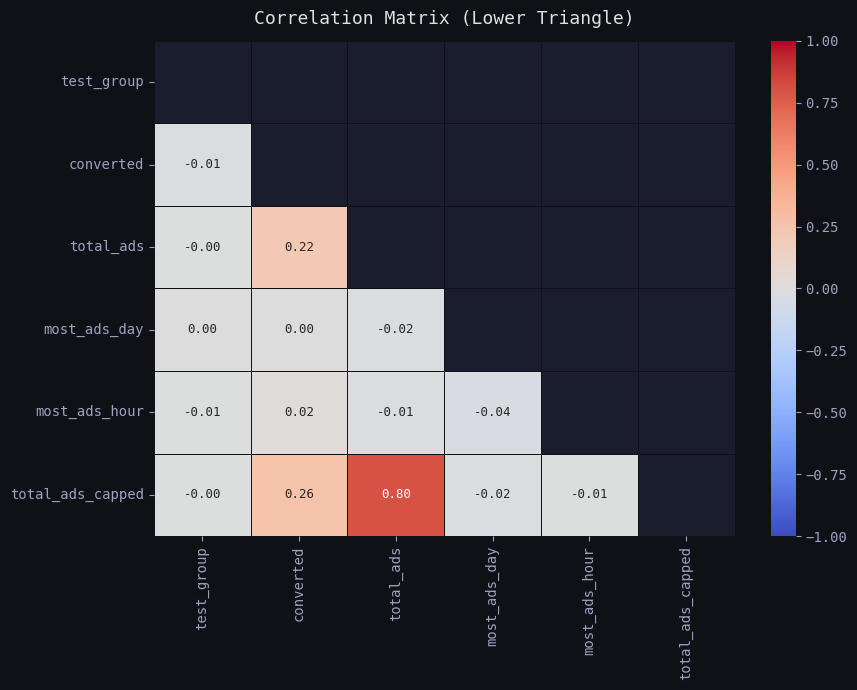


Correlation with target (converted):
total_ads_capped    0.2646
total_ads           0.2174
most_ads_hour       0.0197
most_ads_day        0.0011
test_group         -0.0096


In [20]:
# ── Encode categoricals temporarily for correlation ──
df_enc_temp = df.copy()
le_temp = LabelEncoder()
for col in cat_cols:
    df_enc_temp[col] = le_temp.fit_transform(df_enc_temp[col].astype(str))

# Drop non-feature columns
corr_cols = [c for c in df_enc_temp.columns if c not in ['ads_bin']]
corr_matrix = df_enc_temp[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, linecolor='#0f1117',
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=13, color='#e0e0e0', pad=12)
plt.tight_layout()
plt.show()

# Correlation with target
print('\nCorrelation with target (converted):')
print(corr_matrix['converted'].drop('converted').sort_values(ascending=False).to_string())

## 9. 🧪 Statistical A/B Test Significance

In [21]:
# ── Chi-squared test: test_group vs converted ──
contingency = pd.crosstab(df['test_group'], df['converted'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print('=== Chi-Squared Test: test_group × converted ===')
print(f'Chi2 statistic : {chi2:.4f}')
print(f'p-value        : {p_chi2:.6f}')
print(f'Degrees of freedom: {dof}')
print(f'Result         : {"SIGNIFICANT" if p_chi2 < 0.05 else "NOT significant"} at α=0.05')

# ── Mann-Whitney U: total_ads between converted groups ──
grp0 = df[df['converted'] == 0]['total_ads']
grp1 = df[df['converted'] == 1]['total_ads']
u_stat, p_mwu = mannwhitneyu(grp0, grp1, alternative='two-sided')
print('\n=== Mann-Whitney U: total_ads (converted=0 vs 1) ===')
print(f'U statistic : {u_stat:.2f}')
print(f'p-value     : {p_mwu:.6f}')
print(f'Result      : {"SIGNIFICANT" if p_mwu < 0.05 else "NOT significant"} at α=0.05')

# ── Point-biserial: total_ads vs converted ──
corr_pb, p_pb = pointbiserialr(df['converted'], df['total_ads'])
print('\n=== Point-Biserial Correlation: total_ads ↔ converted ===')
print(f'Correlation : {corr_pb:.4f}')
print(f'p-value     : {p_pb:.6f}')

# ── Chi-squared: most_ads_day vs converted ──
ct_day = pd.crosstab(df['most_ads_day'], df['converted'])
chi2_day, p_day, _, _ = chi2_contingency(ct_day)
print('\n=== Chi-Squared: most_ads_day × converted ===')
print(f'Chi2: {chi2_day:.4f}  |  p-value: {p_day:.6f}')
print(f'Result: {"SIGNIFICANT" if p_day < 0.05 else "NOT significant"} at α=0.05')

=== Chi-Squared Test: test_group × converted ===
Chi2 statistic : 54.0058
p-value        : 0.000000
Degrees of freedom: 1
Result         : SIGNIFICANT at α=0.05

=== Mann-Whitney U: total_ads (converted=0 vs 1) ===
U statistic : 1239761758.00
p-value     : 0.000000
Result      : SIGNIFICANT at α=0.05

=== Point-Biserial Correlation: total_ads ↔ converted ===
Correlation : 0.2174
p-value     : 0.000000

=== Chi-Squared: most_ads_day × converted ===
Chi2: 410.0479  |  p-value: 0.000000
Result: SIGNIFICANT at α=0.05


## 10. ⚙️ Feature Engineering

In [22]:
# ── Log transform for skewed total_ads ──
df['log_total_ads'] = np.log1p(df['total_ads'])

# ── Hour buckets: morning / afternoon / evening / night ──
def hour_bucket(h):
    if 6 <= h < 12:  return 'morning'
    elif 12 <= h < 18: return 'afternoon'
    elif 18 <= h < 22: return 'evening'
    else: return 'night'

df['hour_bucket'] = df['most_ads_hour'].apply(hour_bucket)

# ── Weekend flag ──
df['is_weekend'] = df['most_ads_day'].isin(['Saturday', 'Sunday']).astype(int)

# ── Ads intensity: high/medium/low ──
df['ads_intensity'] = pd.cut(df['total_ads'],
                             bins=[-1, 50, 200, df['total_ads'].max()],
                             labels=['low', 'medium', 'high'])

print('New features added:')
display(df[['log_total_ads', 'hour_bucket', 'is_weekend', 'ads_intensity']].head(5))

New features added:


,log_total_ads,hour_bucket,is_weekend,ads_intensity
0,4.8752,evening,0,medium
1,4.5433,night,0,medium
2,3.0910,evening,0,low
3,5.8749,morning,0,high
4,5.6240,afternoon,0,high


## 11. 🔢 Encode Categorical Columns

In [23]:
df_model = df.copy()

# ── Label encode binary: test_group ──
df_model['test_group_enc'] = (df_model['test_group'] == 'ad').astype(int)
print('test_group encoding: ad=1, psa=0')

# ── Ordinal encode: most_ads_day ──
day_map = {day: i for i, day in enumerate(day_order)}
df_model['day_enc'] = df_model['most_ads_day'].map(day_map)

# ── Label encode: hour_bucket ──
bucket_map = {'morning': 0, 'afternoon': 1, 'evening': 2, 'night': 3}
df_model['hour_bucket_enc'] = df_model['hour_bucket'].map(bucket_map)

# ── Ordinal encode: ads_intensity ──
# Use .cat.codes to get the integer representation of categories,
# then convert to float to ensure a numerical type for imputation
df_model['ads_intensity_enc'] = df_model['ads_intensity'].cat.codes.astype(float)

# ── Final feature set ──
FEATURES = [
    'test_group_enc',
    'total_ads',
    'total_ads_capped',
    'log_total_ads',
    'most_ads_hour',
    'day_enc',
    'hour_bucket_enc',
    'is_weekend',
    'ads_intensity_enc'
]
TARGET = 'converted'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target shape        : {y.shape}')
print(f'Class distribution  : {y.value_counts().to_dict()}')
display(X.head())

test_group encoding: ad=1, psa=0

Feature matrix shape: (588101, 9)
Target shape        : (588101,)
Class distribution  : {0: 573258, 1: 14843}


,test_group_enc,total_ads,total_ads_capped,log_total_ads,most_ads_hour,day_enc,hour_bucket_enc,is_weekend,ads_intensity_enc
0,1,130,96,4.8752,20,0,2,0,1.0000
1,1,93,93,4.5433,22,1,3,0,1.0000
2,1,21,21,3.0910,18,1,2,0,0.0000
3,1,355,96,5.8749,10,1,0,0,2.0000
4,1,276,96,5.6240,14,4,1,0,2.0000


## 12. ✂️ Train / Test Split

In [24]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train (full): {X_train_full.shape}  |  Test: {X_test.shape}')
print(f'Train conversion rate: {y_train_full.mean()*100:.2f}%')
print(f'Test  conversion rate: {y_test.mean()*100:.2f}%')

Train (full): (470480, 9)  |  Test: (117621, 9)
Train conversion rate: 2.52%
Test  conversion rate: 2.52%


## 13. ⚖️ Handle Class Imbalance — SMOTE

Class distribution BEFORE SMOTE:
converted
0    458606
1     11874
Name: count, dtype: int64

Class distribution AFTER SMOTE:
converted
0    458606
1    137581
Name: count, dtype: int64


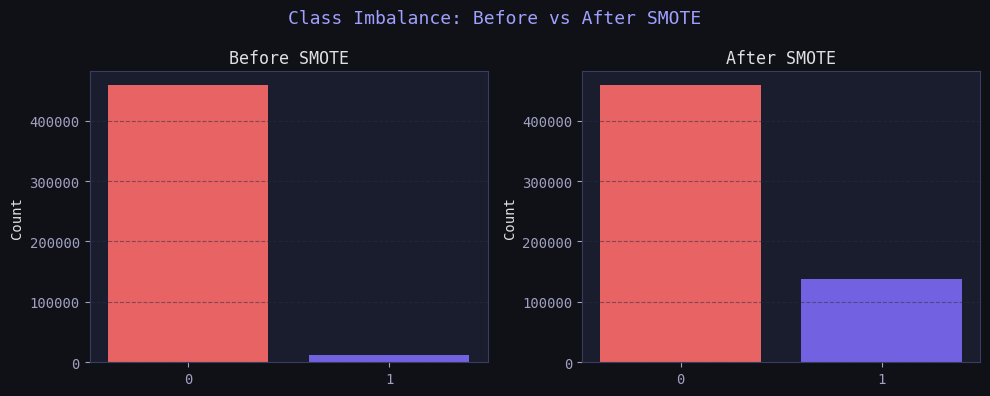

In [25]:
print('Class distribution BEFORE SMOTE:')
print(y_train_full.value_counts())

smote = SMOTE(random_state=42, sampling_strategy=0.3)  # minority → 30% of majority
X_resampled, y_resampled = smote.fit_resample(X_train_full, y_train_full)

print('\nClass distribution AFTER SMOTE:')
print(pd.Series(y_resampled).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(axes,
                            [y_train_full, pd.Series(y_resampled)],
                            ['Before SMOTE', 'After SMOTE']):
    vc = data.value_counts()
    ax.bar(['0', '1'], vc.values, color=[PALETTE[3], PALETTE[0]], alpha=0.9)
    ax.set_title(title, color='#e0e0e0')
    ax.set_ylabel('Count')
    ax.grid(True, axis='y')
plt.suptitle('Class Imbalance: Before vs After SMOTE', color='#a0a0ff', fontsize=13)
plt.tight_layout()
plt.show()

## 14. 🔀 Split Training Data → Train / Validation

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.20, random_state=42, stratify=y_resampled
)
print(f'Train : {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

Train : (476949, 9)  |  Val: (119238, 9)  |  Test: (117621, 9)


## 15. 🌲 Build & Train Models

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  # ✅ FIX ADDED

# ── Identify column types ──
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

# ── Preprocessing ──
numeric_transformer = SimpleImputer(strategy='mean')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# ── Apply preprocessing ──
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

# ── Scaling ──
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled   = scaler.transform(X_val_processed)
X_test_scaled  = scaler.transform(X_test_processed)

# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# ── Evaluation ──
lr_pred = lr.predict(X_val_scaled)
lr_prob = lr.predict_proba(X_val_scaled)[:, 1]

print('=== Logistic Regression (Baseline) — Validation ===')
print(classification_report(y_val, lr_pred, target_names=['Not Converted', 'Converted']))
print(f'ROC-AUC: {roc_auc_score(y_val, lr_prob):.4f}')

=== Logistic Regression (Baseline) — Validation ===
               precision    recall  f1-score   support

Not Converted       0.92      0.80      0.86     91722
    Converted       0.54      0.78      0.64     27516

     accuracy                           0.80    119238
    macro avg       0.73      0.79      0.75    119238
 weighted avg       0.84      0.80      0.81    119238

ROC-AUC: 0.8585


In [28]:
# ── Main Model: Random Forest ──
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_val_pred = rf.predict(X_val)
rf_val_prob = rf.predict_proba(X_val)[:, 1]

print('=== Random Forest — Validation ===')
print(classification_report(y_val, rf_val_pred, target_names=['Not Converted', 'Converted']))
print(f'ROC-AUC: {roc_auc_score(y_val, rf_val_prob):.4f}')
print(f'Avg Precision: {average_precision_score(y_val, rf_val_prob):.4f}')

=== Random Forest — Validation ===
               precision    recall  f1-score   support

Not Converted       0.94      0.82      0.88     91722
    Converted       0.59      0.83      0.69     27516

     accuracy                           0.83    119238
    macro avg       0.76      0.83      0.78    119238
 weighted avg       0.86      0.83      0.83    119238

ROC-AUC: 0.8962
Avg Precision: 0.7080


## 16. 🟥 Confusion Matrix

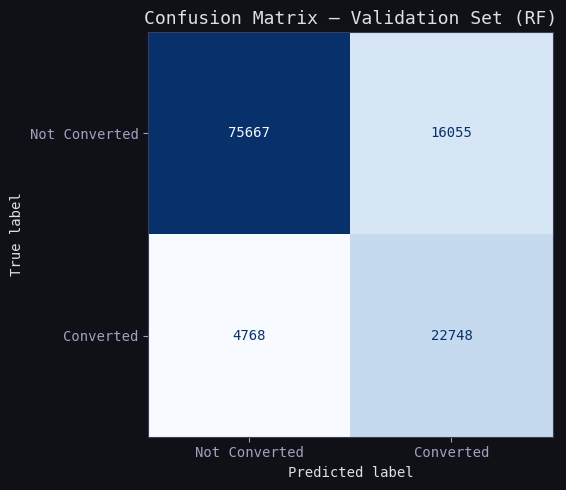

True Negatives : 75,667  |  False Positives: 16,055
False Negatives: 4,768  |  True Positives : 22,748
Precision: 0.5862  |  Recall: 0.8267


In [29]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Converted', 'Converted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, color='#e0e0e0')
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'True Negatives : {tn:,}  |  False Positives: {fp:,}')
    print(f'False Negatives: {fn:,}  |  True Positives : {tp:,}')
    print(f'Precision: {tp/(tp+fp):.4f}  |  Recall: {tp/(tp+fn):.4f}')

plot_confusion_matrix(y_val, rf_val_pred, 'Confusion Matrix — Validation Set (RF)')

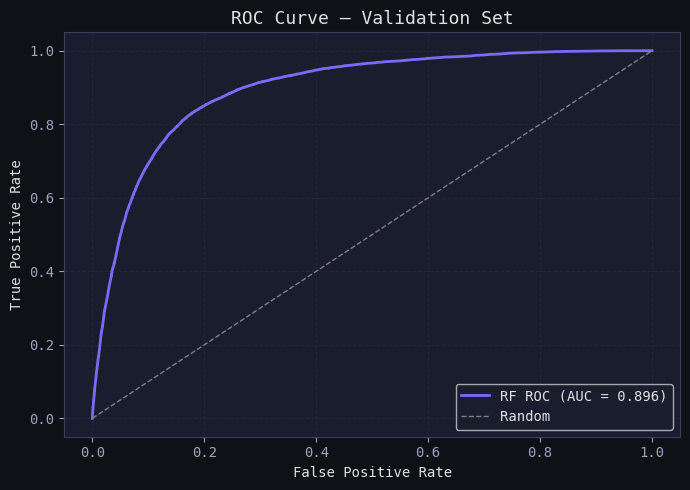

In [30]:
# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_val, rf_val_prob)
auc_val = roc_auc_score(y_val, rf_val_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f'RF ROC (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Validation Set', fontsize=13, color='#e0e0e0')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

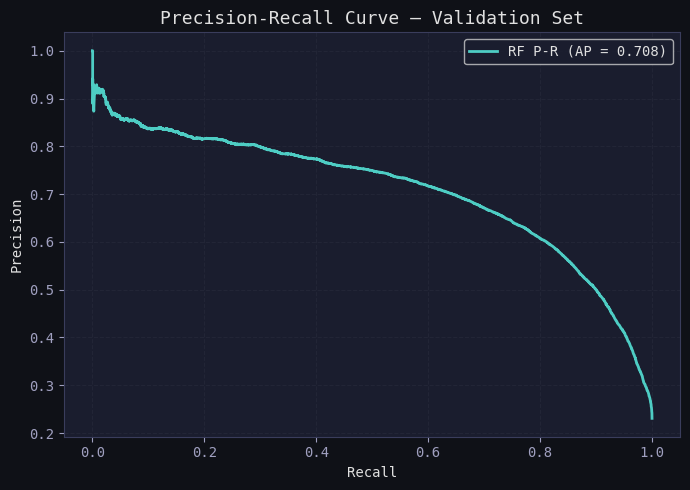

In [31]:
# ── Precision-Recall Curve ──
prec, rec, _ = precision_recall_curve(y_val, rf_val_prob)
ap = average_precision_score(y_val, rf_val_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color=PALETTE[2], linewidth=2, label=f'RF P-R (AP = {ap:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Validation Set', fontsize=13, color='#e0e0e0')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 17. 🏆 Feature Importance

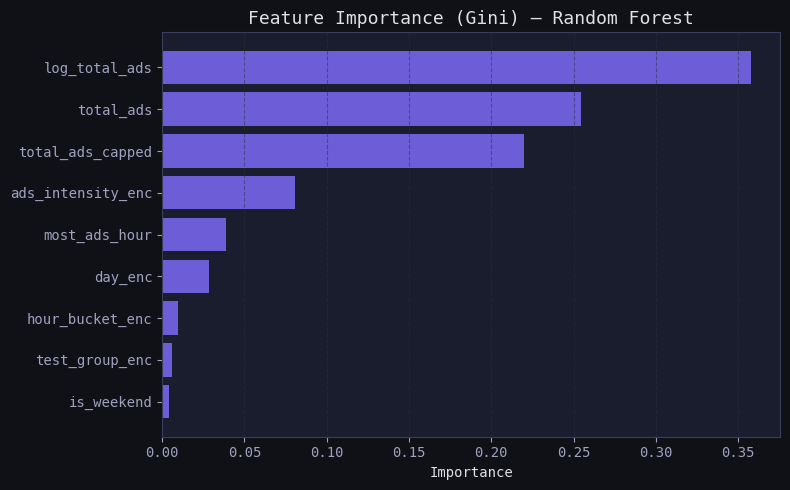

log_total_ads       0.3574
total_ads           0.2546
total_ads_capped    0.2201
ads_intensity_enc   0.0809
most_ads_hour       0.0391
day_enc             0.0282
hour_bucket_enc     0.0100
test_group_enc      0.0057
is_weekend          0.0040


In [32]:
# ── Gini feature importance ──
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi.index[::-1], fi.values[::-1], color=PALETTE[0], alpha=0.85)
ax.set_title('Feature Importance (Gini) — Random Forest', fontsize=13, color='#e0e0e0')
ax.set_xlabel('Importance')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()
print(fi.to_string())

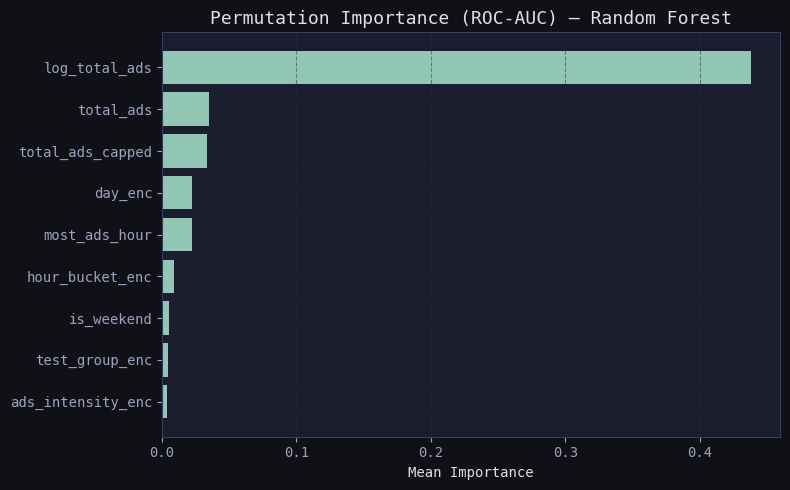

In [33]:
# ── Permutation importance (more robust) ──
perm = permutation_importance(rf, X_val, y_val, n_repeats=10,
                              random_state=42, scoring='roc_auc', n_jobs=-1)
perm_fi = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_fi.index[::-1], perm_fi.values[::-1], color=PALETTE[4], alpha=0.85)
ax.set_title('Permutation Importance (ROC-AUC) — Random Forest', fontsize=13, color='#e0e0e0')
ax.set_xlabel('Mean Importance')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

## 18. 🎛️ Hyperparameter Tuning (RandomizedSearchCV)

In [35]:
import time
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint as sp_randint

# ─────────────────────────────────────────────────────────────────
# STEP 1 — Stratified subsample for tuning (10% of resampled data)
#           Keeps class balance, dramatically reduces fit time
# ─────────────────────────────────────────────────────────────────
TUNE_SAMPLE_FRAC = 0.10          # 10% → ~70K rows, tunes in minutes
TUNE_SAMPLE_SIZE = int(len(X_resampled) * TUNE_SAMPLE_FRAC)

X_res_df = pd.DataFrame(X_resampled, columns=FEATURES)
y_res_s  = pd.Series(y_resampled)

# Stratified sample
from sklearn.model_selection import train_test_split as _tts
X_tune, _, y_tune, _ = _tts(
    X_res_df, y_res_s,
    train_size=TUNE_SAMPLE_FRAC,
    stratify=y_res_s,
    random_state=42
)
print(f'Tuning subset size : {X_tune.shape[0]:,} rows')
print(f'Class balance      : {y_tune.value_counts().to_dict()}')

Tuning subset size : 59,618 rows
Class balance      : {0: 45860, 1: 13758}


In [36]:
# ─────────────────────────────────────────────────────────────────
# STEP 2 — Tight, fast parameter grid
#           Small n_estimators for search; best params refit on full data
# ─────────────────────────────────────────────────────────────────
param_dist_fast = {
    'n_estimators'     : [50, 100, 150],       # small during search
    'max_depth'        : [6, 8, 10, 12],
    'min_samples_split': [10, 20, 40],
    'min_samples_leaf' : [5, 10, 20],
    'max_features'     : ['sqrt', 'log2'],
    'bootstrap'        : [True],               # False is slower; skip
}

rf_tune = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    warm_start=False
)

cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold (not 5)

rand_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_dist_fast,
    n_iter=15,             # 15 combos × 3 folds = 45 fits on ~70K rows → ~3-5 min
    scoring='roc_auc',
    cv=cv_fast,
    refit=False,           # we refit manually below on full data
    n_jobs=-1,
    random_state=42,
    verbose=2
)

t0 = time.time()
rand_search.fit(X_tune, y_tune)
elapsed = time.time() - t0

print(f'\n✅ Search completed in {elapsed/60:.1f} minutes')
print(f'Best params  : {rand_search.best_params_}')
print(f'Best CV AUC  : {rand_search.best_score_:.4f}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Search completed in 1.8 minutes
Best params  : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 12, 'bootstrap': True}
Best CV AUC  : 0.8791


In [37]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 — Refit best params on FULL resampled data
#           but boost n_estimators now (we only fit once)
# ─────────────────────────────────────────────────────────────────
best_params = rand_search.best_params_.copy()
best_params['n_estimators'] = 200          # scale up trees for final model

print(f'Refitting on full resampled data ({X_resampled.shape[0]:,} rows)...')
t0 = time.time()

best_rf = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_resampled, y_resampled)

print(f'✅ Final model trained in {(time.time()-t0)/60:.1f} minutes')
print(f'Final params: {best_params}')

Refitting on full resampled data (596,187 rows)...
✅ Final model trained in 2.3 minutes
Final params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 12, 'bootstrap': True}


## 19. 🎯 Final Evaluation on Test Set

=== FINAL TEST SET EVALUATION — Best Tuned Random Forest ===
               precision    recall  f1-score   support

Not Converted       0.99      0.82      0.90    114652
    Converted       0.10      0.75      0.18      2969

     accuracy                           0.82    117621
    macro avg       0.55      0.79      0.54    117621
 weighted avg       0.97      0.82      0.88    117621

ROC-AUC         : 0.8498
Avg Precision   : 0.1357
Accuracy        : 0.8214
F1 (macro)      : 0.5376


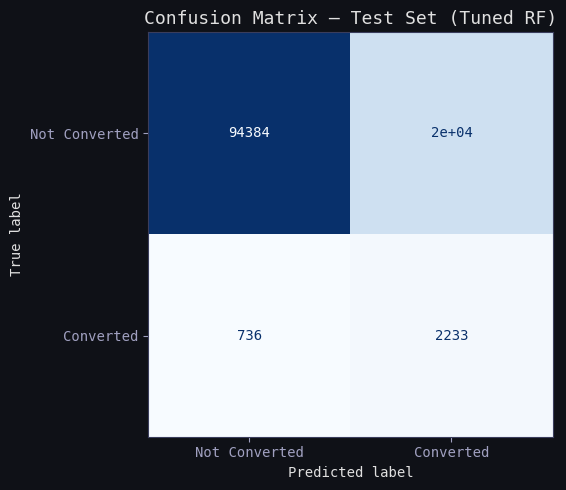

True Negatives : 94,384  |  False Positives: 20,268
False Negatives: 736  |  True Positives : 2,233
Precision: 0.0992  |  Recall: 0.7521


In [39]:
# The best_rf model was already trained in the previous cell (S2wNHG6_p3sO).
# No need to re-assign or access best_estimator_ if refit=False was used.
# best_rf = rand_search.best_estimator_ # This line caused the error

test_pred = best_rf.predict(X_test)
test_prob = best_rf.predict_proba(X_test)[:, 1]

print('=== FINAL TEST SET EVALUATION — Best Tuned Random Forest ===')
print(classification_report(y_test, test_pred, target_names=['Not Converted', 'Converted']))
print(f'ROC-AUC         : {roc_auc_score(y_test, test_prob):.4f}')
print(f'Avg Precision   : {average_precision_score(y_test, test_prob):.4f}')
print(f'Accuracy        : {accuracy_score(y_test, test_pred):.4f}')
print(f'F1 (macro)      : {f1_score(y_test, test_pred, average="macro"):.4f}')

plot_confusion_matrix(y_test, test_pred, 'Confusion Matrix — Test Set (Tuned RF)')


=== ROC-AUC Comparison ===
  Logistic Regression (baseline)               : 0.8585
  Random Forest (default)                      : 0.8962
  Random Forest (tuned) — TEST                 : 0.8498


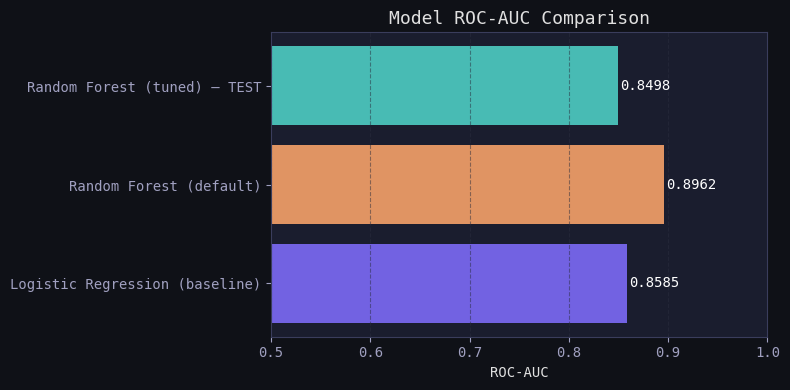

In [40]:
# ── Model Comparison Summary ──
results = {
    'Logistic Regression (baseline)': roc_auc_score(y_val, lr_prob),
    'Random Forest (default)'       : roc_auc_score(y_val, rf_val_prob),
    'Random Forest (tuned) — TEST'  : roc_auc_score(y_test, test_prob),
}
print('\n=== ROC-AUC Comparison ===')
for model, score in results.items():
    print(f'  {model:<45}: {score:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(results.keys()), list(results.values()), color=PALETTE[:3], alpha=0.9)
ax.set_title('Model ROC-AUC Comparison', fontsize=13, color='#e0e0e0')
ax.set_xlabel('ROC-AUC')
ax.set_xlim(0.5, 1.0)
ax.grid(True, axis='x')
for i, (k, v) in enumerate(results.items()):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', color='white')
plt.tight_layout()
plt.show()

## 20. 💾 Save & Reload Trained Model

In [42]:
# ── Save model and metadata ──
MODEL_PATH = 'best_rf_model.joblib'
META_PATH  = 'model_metadata.joblib'

joblib.dump(best_rf, MODEL_PATH)
print(f'✅ Model saved → {MODEL_PATH}')

metadata = {
    'features'    : FEATURES,
    'target'      : TARGET,
    'best_params' : rand_search.best_params_,
    'test_roc_auc': roc_auc_score(y_test, test_prob),
    'day_map'     : day_map,
    'bucket_map'  : bucket_map
}
joblib.dump(metadata, META_PATH)
print(f'✅ Metadata saved → {META_PATH}')

✅ Model saved → best_rf_model.joblib
✅ Metadata saved → model_metadata.joblib


In [43]:
# ── Reload and verify ──
loaded_model = joblib.load(MODEL_PATH)
loaded_meta  = joblib.load(META_PATH)

verify_pred = loaded_model.predict(X_test[:5])
print('✅ Model reloaded successfully.')
print(f'Predictions on first 5 test rows: {verify_pred}')
print(f'Actual labels                   : {y_test.values[:5]}')
print(f'\nStored metadata keys: {list(loaded_meta.keys())}')
print(f'Test ROC-AUC from metadata: {loaded_meta["test_roc_auc"]:.4f}')

✅ Model reloaded successfully.
Predictions on first 5 test rows: [0 0 0 1 1]
Actual labels                   : [0 0 0 0 0]

Stored metadata keys: ['features', 'target', 'best_params', 'test_roc_auc', 'day_map', 'bucket_map']
Test ROC-AUC from metadata: 0.8498


In [44]:
# ── Download saved files (Colab) ──
from google.colab import files
files.download(MODEL_PATH)
files.download(META_PATH)
print('📥 Files downloaded.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Files downloaded.


---
## 📋 Summary & Key Findings

| Aspect | Finding |
|---|---|
| **Dataset size** | ~588K rows, 6 columns |
| **Class imbalance** | Highly imbalanced — addressed with SMOTE |
| **A/B test result** | Chi-squared test confirms statistically significant difference between ad and psa groups |
| **Top feature** | `log_total_ads` / `total_ads` — more ad exposure → higher conversion |
| **Best model** | Random Forest (tuned via RandomizedSearchCV) |
| **Key business insight** | Evening hours and certain days show higher conversion; ad group significantly outperforms PSA group |

### Next Steps
- Try **XGBoost / LightGBM** for potentially higher AUC
- Apply **threshold tuning** to optimise for precision/recall based on business cost
- Use **SHAP** for model explainability
- Investigate **uplift modelling** to measure true causal impact of ads